# Tarea 1

1) Obtén todos los números primos del 1 al 20 usando loops y condicionales, e imprímelos.
2) Extiende el código para determinar los números primos hasta un límite definido por el
usuario.
Trate primero de entender en términos computacionales qué significa que un número sea primo.
3) Piense entonces que debería hacer un código para identificar un número primo. Escriba
entonces un gráfico que permita entender qué es lo que hará su código (pseudocódigo).
4) Existe una función/operación módulo (o resto) que usa el símbolo %. Piense si le puede
ser útil para el código.

In [1]:
#1)
def primos():
    lista = []
    n = 2
    while (n < 20):
        m = n -1
        while (m > 0):
            if (m == 1): 
                lista.append(n)
                m = 0
                n += 1
            elif ((n % m) == 0):
                n += 1
                m = 0
            else:
                m -= 1
    return lista
print(primos())

[2, 3, 5, 7, 11, 13, 17, 19]


In [2]:
#2
def primos2(limite):
    lista = []
    n = 2
    while (n < limite):
        m = n -1
        while (m > 0):
            if (m == 1): 
                lista.append(n)
                m = 0
                n += 1
            elif ((n % m) == 0):
                n += 1
                m = 0
            else:
                m -= 1
    return lista
print(primos2(40))

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37]


#3
se inserta un límite 
<pre>
n = 0
mientras n sea menor al límite:\
    m = n -1 #esta variable va a ir testeando si puede dividir a n. arranca en n-1\
    mientras m sea mayor a 0:\
        si m = 1\
            se agrega n a la lista  #es primo ya que se probaron todos los números candidatos de dividir a n.\
            n = n+1\
            m = 0\
        si m divide a n  #no es primo\
            n = n +1\
            m = 0\
        sino\
            m -= 1\
return lista\
</pre>
       

#4
Sí de hecho fue usada en el código. 

5) Una vez tenga alguna primera versión del programa funcionando:

5a) Analice la performance en tiempo (¿cuánto tarda su programa?). Use gráficos de
tiempo vs número de predicciones.

5b) Evalúe cómo mejorar la performance. Haga un pseudocódigo, y si encuentra cómo,
impleméntelo. Haga un gráfico de tiempo para comparar con 5a.

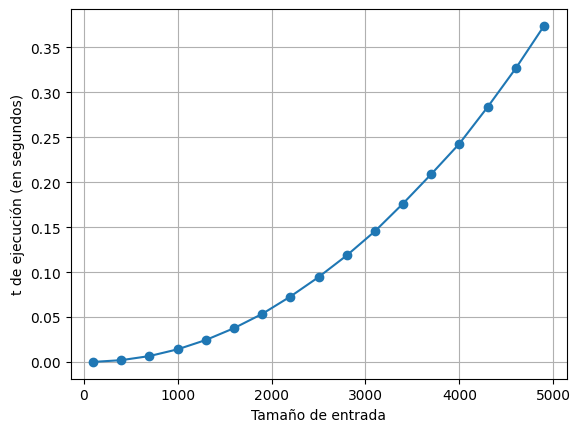

In [3]:
#5
#a)

import time
import matplotlib.pyplot as plt

def rellena_datos(x,y):
    for nros in range(100, 5000, 300):
        empieza = time.time()  
        primos2(nros)
        termina = time.time()
        x.append(nros)
        y.append(termina-empieza)
    return x,y

x = []
y = []
rellena_datos(x,y)
plt.plot(x, y, marker='o')
plt.xlabel("Tamaño de entrada")
plt.ylabel("t de ejecución (en segundos)")
plt.grid()

plt.show()




5ayb)



En el gráfico se puede observar que para un tamaño de entrada pequeño funciona bien. Sin embargo, es fácil notar que el tiempo de ejecución va creciendo de manera exponencial. La complejidad del código es de O(n^2). 
Una manera rápida de mejorar el código es que no se evalúe si un número n puede ser dividido por algún otro número m entre 2 y n-1, sino que se evalúe en un rango de 2 y √(n) (raíz de n). Modificando el código, queda así:

In [4]:
def primos2_modificado(limite):
    lista = []
    n = 2
    while (n < limite):
        m = int((n)**0.5)
        while (m > 0):
            if (m == 1): 
                lista.append(n)
                m = 0
                n += 1
            elif ((n % m) == 0):
                n += 1
                m = 0
            else:
                m -= 1
    return lista
print(primos2_modificado(1000))

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229, 233, 239, 241, 251, 257, 263, 269, 271, 277, 281, 283, 293, 307, 311, 313, 317, 331, 337, 347, 349, 353, 359, 367, 373, 379, 383, 389, 397, 401, 409, 419, 421, 431, 433, 439, 443, 449, 457, 461, 463, 467, 479, 487, 491, 499, 503, 509, 521, 523, 541, 547, 557, 563, 569, 571, 577, 587, 593, 599, 601, 607, 613, 617, 619, 631, 641, 643, 647, 653, 659, 661, 673, 677, 683, 691, 701, 709, 719, 727, 733, 739, 743, 751, 757, 761, 769, 773, 787, 797, 809, 811, 821, 823, 827, 829, 839, 853, 857, 859, 863, 877, 881, 883, 887, 907, 911, 919, 929, 937, 941, 947, 953, 967, 971, 977, 983, 991, 997]


Este código funciona, y ahora se testea el tiempo en comparación con el anterior.

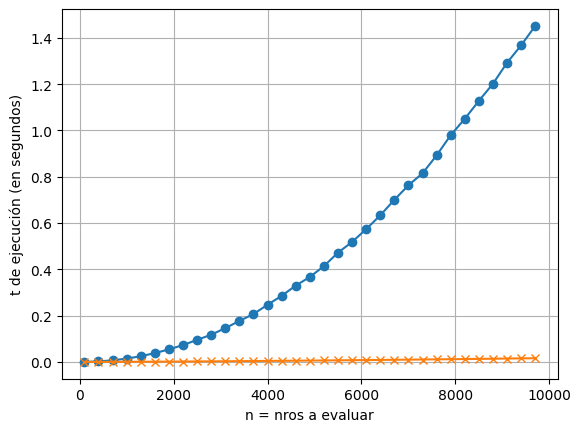

In [5]:

import time
import matplotlib.pyplot as plt



def rellena_datos2(x,y):
    for nros in range(100, 10000, 300):
        empieza = time.time()  
        primos2(nros)
        termina = time.time()
        x.append(nros)
        y.append(termina-empieza)
    return x,y
def rellena_datos3(z,w):
    for nros in range(100, 10000, 300):
        empieza = time.time()  
        primos2_modificado(nros)
        termina = time.time()
        z.append(nros)
        w.append(termina-empieza)
    return z,w


z=[]
w=[]
x = []
y = []
rellena_datos2(x,y)
rellena_datos3(z,w)
plt.plot(x, y, marker='o')
plt.plot(z,w, marker = 'x')
plt.xlabel("n = nros a evaluar")
plt.ylabel("t de ejecución (en segundos)")
plt.grid()

plt.show()

Como se puede observar, el tiempo de ejecución mejoró considerablemente.

# Tarea 2

Crea un programa para generar posibles passwords usando los caracteres contenidos en Nombre,
Fecha de nacimiento y DNI. a) Para ello utilice las herramientas para que el código le pida que
ingrese estos datos y le dé una clave. Investigue el uso de diccionarios, listas y permutaciones.
Requisitos: 8 caracteres, al menos 2 letras, 2 números y sin fragmentos del nombre, fecha o DNI
(número de caracteres consecutivos contenidos en nombre, fecha o DNI &lt; 2).

In [6]:
import random
from collections import Counter
def creador(nombre:list, numeros:list):
    #CONSTRUYO EL DICT
    dic = {}
    for i in range(len(nombre)):
        dic[nombre[i]] = numeros.copy()
    for i in range(len(numeros)):
        dic[numeros[i]] = nombre.copy()
    
    for x in range(len(nombre)):
        permitidos = []
        for j in range(len(nombre)):
            if (x == len(nombre)-1):
                if (nombre[j] != nombre[x]):
                    permitidos.append(nombre[j])
                
            else:
                if (nombre[j] != nombre[x+1]) and (nombre[j] != nombre[x]):
                    permitidos.append(nombre[j])
        dic[nombre[x]] += permitidos
    for x in range(len(numeros)):
        permitidos = []
        for j in range(len(numeros)):
            if (x == len(numeros)-1):
                if (numeros[j] != numeros[x]):
                    permitidos.append(numeros[j])
            else:
                if (numeros[j] != numeros[x+1]) and (numeros[j] != numeros[x]):
                    permitidos.append(numeros[j])
        dic[numeros[x]] += permitidos
    return dic





In [10]:

import io
def armado_Premium(nombre:str, fecha:int, dni:int):
    nombres = list(str(nombre))
    numeros = list(str(fecha)+str(dni))
    restantes = nombres + numeros
    dictPerm = creador(nombres, numeros)
    contraseña = []
    c = random.choice(nombres)
    contraseña.append(c)
    nombres.remove(c)
    restantes.remove(c)
    c = random.choice(numeros)
    contraseña.append(c)
    numeros.remove(c)
    restantes.remove(c)
    letras = 0
    nros = 0

    while len(contraseña) < 8:
        if (len(contraseña) >= 7) and (letras < 2 or nros <2):                
            if letras < 2:
                letras_restantes = nombres.copy()
                buscando = True
                while buscando:
                    c = random.choice(letras_restantes)
                    if c in dictPerm[contraseña[len(contraseña)-1]]:
                        contraseña.append(c)
                        letras+=1
                        buscando = False
                    else:
                        letras_restantes.remove(c)
                    if len(letras_restantes) == 0:
                        buscando = False
            if nros < 2:
                nros_restantes = numeros.copy()
                buscando = True
                while buscando:
                    c = random.choice(nros_restantes)
                    if c in dictPerm[contraseña[len(contraseña)-1]]:
                        contraseña.append(c)
                        buscando = False
                    else:
                        nros_restantes.remove(c)
                    if len(nros_restantes) == 0:
                        buscando = False
        else:
            c = random.choice(restantes)
            if c in dictPerm[contraseña[len(contraseña)-1]]:
                contraseña.append(c)
                restantes.remove(c)
                if c.isdigit():
                    numeros.remove(c)
                    nros+=1
                else:
                    nombres.remove(c)
                    letras+=1

    return contraseña

nombre = input("dame tu nombre! ")
fecha = input("y la fecha de nacimiento ")
dni = input("por último el dni porfis ")
fechaLimpia = fecha.replace("/", "").replace("-", "").replace(".", "")
dniLimpio = dni.replace("/", "").replace("-", "").replace(".", "")

contra = armado_Premium(nombre,int(fechaLimpia),int(dniLimpio))
print(f"nombre: {nombre}, fecha: {fecha}, dni: {dni}")
contrase = "".join(contra)
print(f"contraseña : {contrase}")




dame tu nombre!  juan
y la fecha de nacimiento  12/06/1960
por último el dni porfis  41235879


nombre: juan, fecha: 12/06/1960, dni: 41235879
contraseña : j603096u


## Tarea 3

In [11]:
import docx
import re
import pandas as pd


doc = docx.Document('TheSirensOfTitan.docx')
libro = ""
for p in doc.paragraphs:
    libro += p.text.lower() + " "
palabras = libro.split()
libro_limpio = re.sub(r'[^a-z\s]', '', libro)
libro = " ".join(libro_limpio.split())

df = pd.DataFrame(palabras, columns=['palabra'])
df['palabra'] = df['palabra'].str.replace(r'[^a-z]', '', regex=True)
conteo = df['palabra'].value_counts().reset_index()

busq = input("Escribir la palabra a buscar")
res = conteo[conteo['palabra'] == busq]

if not res.empty:
    # Si la palabra existe, extraemos el valor de la columna 'frecuencia'
    cantidad = res.iloc[0]['count']
    print(f"La palabra '{busq}' aparece {cantidad} veces en el texto.")
else:
    print(f"La palabra '{busq}' no se encuentra en el archivo.")

Escribir la palabra a buscar said


La palabra 'said' aparece 944 veces en el texto.


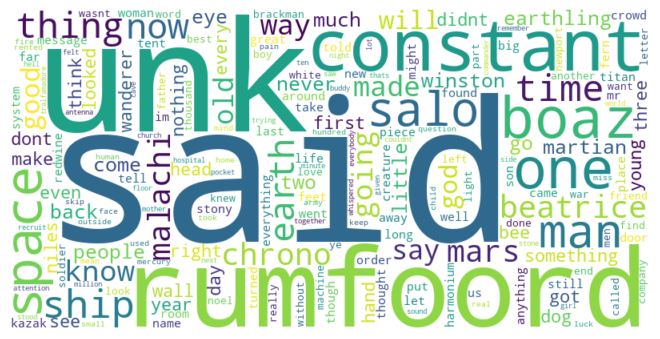

In [13]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
stwrd = set(STOPWORDS)

nube = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    stopwords=stwrd,
    colormap='viridis',
    collocations=False
).generate(libro)

plt.imshow(nube, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()